# MPGraph: Patient-level Prediction and Prototype Visualization

This notebook demonstrates how to apply a pretrained MPGraph model to
whole-slide images (WSIs) feature representations for patient-level
survival risk prediction and prototype-based tissue visualization.

The workflow consists of four major steps:

1. Load pretrained MPGraph model and select cancer type.
2. Generate patient-level survival risk scores from patch-level features.
3. Quantify predictive performance using the concordance index (C-index)
   and time-integrated area under the ROC curve (iAUC).
4. Project prototype assignments back onto the WSIs to visualize the
   histological patterns described by MPGraph.

The notebook is intended as a reproducible example for users who want to
apply the pretrained model to an external cohort.

> **Input:** Patch-level feature files (`.h5`) and a metadata CSV file.
>
> **Output:** Patient-level risk scores, survival prediction metrics,
> prototype assignment maps, and WSIs-level visualization.

In [1]:
import os
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch_geometric.data import Data

from sksurv.metrics import (concordance_index_censored, cumulative_dynamic_auc)
from sksurv.util import Surv

# Add the project root to the Python path
PROJECT_ROOT = Path("../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from models.panther.base_layers import PrototypeTokenizer
from models.model_mpgraph import MPGraph_Surv
from utils.vis_utils import load_panther_encoder
from utils.graph_utils import (
    wasserstein_distance,
    symmetric_normalization,
)

## Input requirements

The prediction workflow requires:

- A metadata CSV file containing at least:
  - `case_id`: patient-level identifier
  - `slide_id`: WSI identifier
  - `time`: survival time
  - `status`: event indicator
- One HDF5 feature file (`.h5`) for each WSI.
- Each HDF5 file must contain a dataset named `features`.

In [ ]:
# -------------------------
# Model configuration
# -------------------------

CANCER_TYPE = "RCC"
INPUT_DIM = 1024
N_PROTOTYPES = 8

# -------------------------
# Hardware configuration
# -------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# -------------------------
# Data paths
# -------------------------

# Update these paths according to the local dataset organization.
DATA_DIR = Path("../data")

CSV_PATH = DATA_DIR / "metadata.csv"
FEATURE_DIR = DATA_DIR / "features"

# Pretrained MPGraph checkpoint.
CHECKPOINT_PATH = Path("../checkpoints/MPGraph.pt")

Using device: cuda


## Patient-level Survival Prediction

In [ ]:
### Loading PANTHER Encoder
panther_encoder = load_panther_encoder(
    cancer_type=CANCER_TYPE,
    checkpoint_path=str(CHECKPOINT_PATH),
    in_dim=INPUT_DIM,
    n_proto=N_PROTOTYPES,
    iter=1,
)
panther_encoder.to(DEVICE)

### Loading Tokenizer
tokenizer = PrototypeTokenizer(out_type="allcat",p=N_PROTOTYPES,)
tokenizer.to(DEVICE)

### Loading MPGraph Model
model = MPGraph_Surv(input_dim=INPUT_DIM, p=N_PROTOTYPES)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint[CANCER_TYPE]["weights"])
model.to(DEVICE)
model.eval()

print("Pretrained models loaded successfully.")

Pretrained models loaded successfully.


In [6]:
def predict(
    csv_path,
    feature_path,
    panther_encoder,
    tokenizer,
    model,
    n_proto,
    device
):
    """
    Generate patient-level survival risk scores from WSI features.

    Parameters
    ----------
    csv_path : Path to the metadata CSV file. The table must contain
        `case_id`, `slide_id`, `time`, and `status`.

    feature_path : Directory containing one HDF5 feature file per WSI.

    panther_encoder : PANTHER encoder.

    tokenizer : Prototype tokenizer used to obtain prototype-level
        probabilities, means, and covariance representations.

    model : Pretrained MPGraph survival model.

    n_proto : Number of morphological prototypes.

    device : Device used for inference.

    Returns
    -------
    c_index : Harrell's concordance index.

    iAUC : Mean cumulative/dynamic AUC evaluated over the predefined survival-time range.

    patient_results : Patient-level prediction results containing:
        `patient`, `risk`, `survival`, and `status`.
    """  
    preddata = pd.read_csv(csv_path)
    predcase = preddata.drop_duplicates('case_id')['case_id'].tolist()

    all_status = []
    all_event_times = []
    all_risk_scores = []
    for case in tqdm(predcase):
        slide_ids = list(preddata.loc[preddata['case_id']==case, 'slide_id']) # type: ignore
        assert len(slide_ids) > 0, f'No slide found for case {case}'
        if isinstance(slide_ids, str):
            slide_ids = [slide_ids]
        feat_paths = [os.path.join(feature_path, str(slide_name) + '.h5') for slide_name in slide_ids]
        all_features = []
        for feat_path in feat_paths:
            with h5py.File(feat_path, 'r') as f:
                features = f['features'][:] # type: ignore
            all_features.append(features)
        all_features = torch.from_numpy(np.concatenate(all_features, axis=0))
        all_event_times.append(preddata.loc[preddata['case_id']==case, 'time'].iloc[0]) # type: ignore
        all_status.append(preddata.loc[preddata['case_id']==case, 'status'].iloc[0]) # type: ignore
        
        with torch.inference_mode():
            out = panther_encoder(all_features.unsqueeze(dim=0).to(device)) # type: ignore
            prob, mean, cov = tokenizer.forward(out)
            adj = torch.zeros((n_proto,n_proto))
            for i in range(n_proto):
                for j in range(i + 1, n_proto):
                    dist = wasserstein_distance(mean[0][i], cov[0][i], mean[0][j], cov[0][j]) # type: ignore
                    adj[i, j] = 1/(dist + 1e-10)
                    adj[j, i] = 1/(dist + 1e-10)
            adj = symmetric_normalization(adj)
            for i in range(n_proto):
                adj[i, i] = prob[0][i]
            edge_index = torch.nonzero(adj, as_tuple=False).t()
            edge_weight = adj[edge_index[0], edge_index[1]].type(torch.float32)
            features = Data(x=mean, edge_index=edge_index, edge_attr=edge_weight)
            features.batch =  torch.tensor(np.zeros(n_proto, dtype=int).tolist())      
            _, risk = model(features.to(device)) # type: ignore
            all_risk_scores.append(risk.cpu().item())

    # ===== C-Index ===== #
    c_index = concordance_index_censored((np.array(all_status)).astype(bool), np.array(all_event_times), np.array(all_risk_scores), tied_tol=1e-08)[0]
    print(f'C-index: {c_index:.4f}')

    # ===== Time-integrated AUC ===== #
    y_surv = Surv.from_arrays(event=np.array(all_status).astype(bool),time=np.array(all_event_times))
    event_times = np.array(all_event_times)[np.array(all_status) == 1]
    t_lower = np.quantile(event_times, 0.20)
    t_upper = np.quantile(event_times, 0.81)
    K = 10
    eval_times = np.linspace(t_lower, t_upper, K)
    auc_times, auc_values = cumulative_dynamic_auc(y_surv,y_surv,np.array(all_risk_scores),eval_times)
    iAUC = np.mean(auc_values)
    print(f"Time-integrated AUC: {iAUC:.4f}")
    
    patient_results = pd.DataFrame({'patient': predcase, 
                                    'risk': all_risk_scores, 
                                    'survival': all_event_times, 
                                    'status': all_status})
    return c_index, iAUC, patient_results

In [7]:
# ============================================================
# Run patient-level prediction
# ============================================================

c_index, iAUC, patient_results = predict(
    csv_path=CSV_PATH,
    feature_path=FEATURE_DIR,
    panther_encoder=panther_encoder,
    tokenizer=tokenizer,
    model=model,
    n_proto=N_PROTOTYPES,
    device=DEVICE,
)

print("\nPrediction summary")
print("------------------")
print(f"Number of patients : {len(patient_results)}")
print(f"C-index            : {c_index:.4f}")
print(f"Time-integrated AUC     : {iAUC:.4f}")

100%|██████████| 237/237 [02:38<00:00,  1.49it/s]

C-index: 0.7163
Time-integrated AUC: 0.7193

Prediction summary
------------------
Number of patients : 237
C-index            : 0.7163
Time-integrated AUC     : 0.7193


## WSI-level prototype visualization

In [7]:
import cv2
import openslide

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw

from utils.vis_utils import hex_to_rgb_mpl_255

In [ ]:
def visualize_wsi_clusters(
    slide_fpath,
    coords,
    cluster_labels,
    patch_size=256,
    patch_level=0,
    vis_level=None,
    alpha=0.3,
    custom_colors=None,
    line_width=1,
):
    """
    Overlay patch-level prototype assignments on a WSI thumbnail.

    Parameters
    ----------
    slide_fpath : str or Path
        Path to the whole-slide image.

    coords : np.ndarray
        Patch coordinates with shape `(N, 2)`. Coordinates should
        correspond to the specified `patch_level`.

    cluster_labels : np.ndarray
        Integer prototype label assigned to each patch.

    patch_size : int, default=256
        Patch size in pixels at `patch_level`.

    patch_level : int, default=0
        OpenSlide pyramid level corresponding to the patch coordinates.

    vis_level : int or None, default=None
        Pyramid level used for visualization. If None, level 3 is
        selected when available, otherwise the lowest available level
        is used.

    alpha : float, default=0.3
        Opacity of the prototype overlay.

    custom_colors : list or None, default=None
        Optional RGB color list for prototype visualization. If None,
        a Matplotlib categorical colormap is used.

    line_width : int, default=1
        Width of the patch boundary. Set to 0 to disable boundaries.

    Returns
    -------
    thumbnail : PIL.Image.Image
        Original WSI thumbnail.

    blended : PIL.Image.Image
        WSI thumbnail with prototype assignments overlaid.
    """

    # ------------------------------------------------------------
    # 1. Open the WSI
    # ------------------------------------------------------------
    wsi = openslide.open_slide(slide_fpath)

    if vis_level is None:
        vis_level = min(3, wsi.level_count - 1)

    print(f"[INFO] Visualization level: {vis_level}")

    # ------------------------------------------------------------
    # 2. Read the WSI thumbnail
    # ------------------------------------------------------------
    vis_dims = wsi.level_dimensions[vis_level]
    thumbnail = wsi.read_region(location=(0, 0), level=vis_level, size=vis_dims).convert("RGB")

    overlay = Image.new("RGBA", vis_dims, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    # ------------------------------------------------------------
    # 3. Convert patch coordinates between pyramid levels
    # ------------------------------------------------------------
    downsample_vis = wsi.level_downsamples[vis_level]
    downsample_patch = wsi.level_downsamples[patch_level]
    scale = downsample_patch / downsample_vis

    vis_patch_size = int(np.ceil(patch_size * scale))

    # ------------------------------------------------------------
    # 4. Define prototype colors
    # ------------------------------------------------------------
    n_clusters = int(cluster_labels.max()) + 1

    if custom_colors is None:
        cmap = plt.get_cmap("tab10", n_clusters)
        colors = [
            tuple((np.array(cmap(i)[:3]) * 255).astype(np.uint8))
            for i in range(n_clusters)
        ]
    else:
        colors = custom_colors

    # ------------------------------------------------------------
    # 5. Render prototype assignments
    # ------------------------------------------------------------
    for (x, y), label in zip(coords, cluster_labels):

        x_vis = int(x / downsample_vis)
        y_vis = int(y / downsample_vis)

        color = colors[label]

        draw.rectangle(
            [
                x_vis,
                y_vis,
                x_vis + vis_patch_size,
                y_vis + vis_patch_size
            ],
            fill=(*color, int(255 * alpha)),
            outline=color if line_width > 0 else None,
            width=line_width
        )

    # ------------------------------------------------------------
    # 6. Composite the overlay with the original thumbnail
    # ------------------------------------------------------------
    blended = Image.alpha_composite(
        thumbnail.convert("RGBA"),
        overlay
    ).convert("RGB")

    return thumbnail, blended

### Note on tumor annotations.
>
> The tumor-region annotations used in this visualization are obtained
> from a publicly available Zenodo dataset containing manual QuPath
> annotations for TCGA diagnostic WSIs. 

Loeffler, C., & Kather, J. N. (2021). Manual tumor annotations in TCGA (Version v0.1) [Dataset]. Zenodo. https://doi.org/10.5281/zenodo.5320076

> These annotations are available
> only for the corresponding TCGA cases and are **not available for all
> cohorts or patients**.
>
> Accordingly, tumor-region overlay is an optional visualization and
> can only be performed for WSIs with a matching annotation file.
> For other cohorts, prototype maps can still be visualized without
> tumor annotations.

In [ ]:
def overlay_tumor_annotation_on_wsi(
    slide_fpath,
    csv_fpath,
    target_level=3,
    alpha=0.6,
    mask_color=(255, 0, 0),
):
    """
    Overlay an tumor annotation on a WSI thumbnail.

    Parameters
    ----------
    slide_fpath : str or Path
        Path to the whole-slide image (WSI).

    csv_fpath : str or Path
        Path to the QuPath annotation CSV file.

    target_level : int, default=3
        OpenSlide pyramid level used for visualization. If the requested
        level is unavailable, the lowest available pyramid level is used.

    alpha : float, default=0.6
        Opacity of the tumor annotation overlay.

    mask_color : tuple, default=(255, 0, 0)
        RGB color used to represent the tumor annotation.

    Returns
    -------
    original_thumbnail : np.ndarray
        Original WSI thumbnail at the selected pyramid level.

    annotated_thumbnail : np.ndarray
        WSI thumbnail with the tumor annotation overlaid.
    """

    # ------------------------------------------------------------
    # 1. Load the WSI and generate a thumbnail
    # ------------------------------------------------------------

    wsi = openslide.open_slide(slide_fpath)

    if target_level >= wsi.level_count:
        target_level = wsi.level_count - 1

    size = wsi.level_dimensions[target_level]

    wsi_thumb = (
        wsi.read_region(
            (0, 0),
            target_level,
            size,
        )
        .convert("RGB")
    )

    wsi_thumb_np = np.array(wsi_thumb)
    ds = wsi.level_downsamples[target_level]

    # ------------------------------------------------------------
    # 2. Load and identify QuPath annotation coordinates
    # ------------------------------------------------------------

    df = pd.read_csv(csv_fpath)
    x_col = [col for col in df.columns if "X_base" in col][0]
    y_col = [col for col in df.columns if "Y_base" in col][0]

    # ------------------------------------------------------------
    # 3. Parse annotation coordinates and convert them to the
    #    visualization coordinate system
    # ------------------------------------------------------------

    all_contours = []
    current_poly = []

    x_arr = df[x_col].astype(str).values
    y_arr = df[y_col].astype(str).values

    print("[INFO] Parsing QuPath annotations and ""projecting coordinates to the visualization level...")

    for val_x, val_y in zip(x_arr, y_arr):

        val_x_clean = val_x.strip()
        val_y_clean = val_y.strip()

        if (
            "X_base" in val_x_clean
            or "Y_base" in val_y_clean
            or val_x_clean in ["nan", ""]
        ):
            if len(current_poly) > 0:
                all_contours.append(
                    np.array(
                        current_poly,
                        dtype=np.int32,
                    )
                )
                current_poly = []

            continue

        try:
            x_vis = int(float(val_x_clean) / ds)
            y_vis = int(float(val_y_clean) / ds)
            current_poly.append([x_vis, y_vis])

        except ValueError:
            continue

    if len(current_poly) > 0:
        all_contours.append(
            np.array(
                current_poly,
                dtype=np.int32,
            )
        )

    print(
        f"[INFO] Parsed {len(all_contours)} annotation objects "
        "(including polygon contours and rectangular regions)."
    )

    # ------------------------------------------------------------
    # 4. Render the tumor annotation
    # ------------------------------------------------------------
    overlay = wsi_thumb_np.copy()
    if len(all_contours) > 0:
        cv2.drawContours(
            overlay,
            all_contours,
            -1,
            color=mask_color,
            thickness=-1,
        )

    # ------------------------------------------------------------
    # 5. Blend the annotation with the original WSI
    # ------------------------------------------------------------
    output_thumb = cv2.addWeighted(
        wsi_thumb_np,
        1 - alpha,
        overlay,
        alpha,
        0,
    )

    return wsi_thumb_np, output_thumb

[INFO] 成功载入数据。坐标数量: 17434, 特征维度: torch.Size([17434, 1024])
[INFO] 正在通过 PANTHER 模型提取表征与聚类群组...
[INFO] Visualization level: 3
[INFO] 正在叠加 PNG 肿瘤标注...
[INFO] 正在对混合标注数据进行流式清洗与坐标投影...
[INFO] 解析完成。共检测到 1 个标注单元（含轮廓与网格方块）。


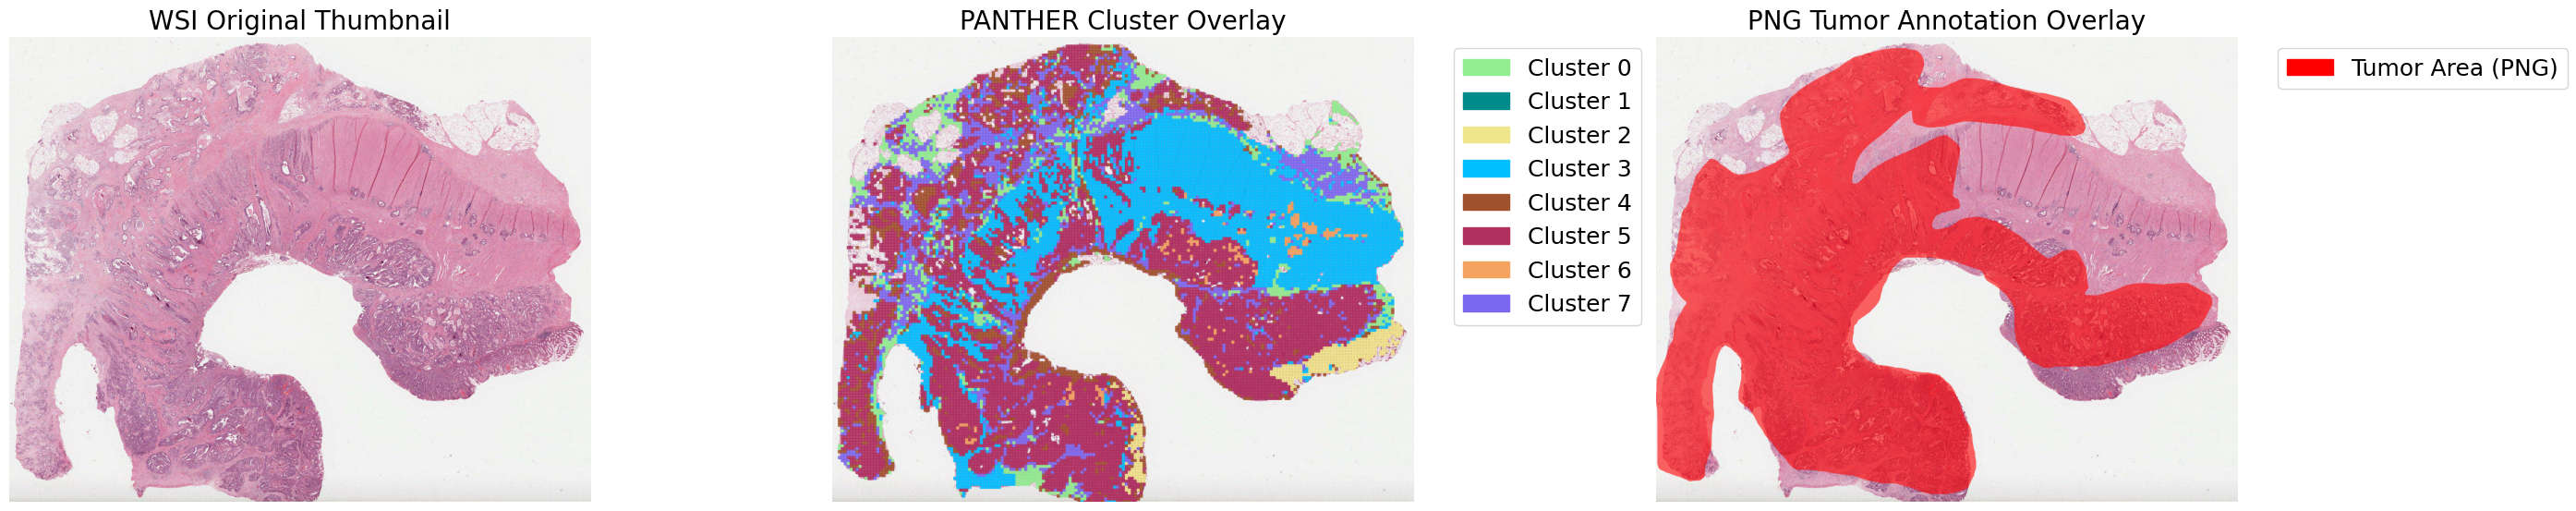

In [ ]:
slide_fpath = ("/path/to/your/WSI.svs")
h5_feats_fpath = ("/path/to/your/features.h5")
# Optional: path to the external QuPath tumor annotation.
# Set this to None when no matching annotation is available.
csv_fpath = ("/path/to/your/tumor_annotation.csv")


# 1. Load WSI coordinates and patch-level features
# The HDF5 file is expected to contain:
#   - `coords`: patch coordinates in the original WSI coordinate system
#   - `features`: patch-level feature representations
wsi = openslide.open_slide(slide_fpath)
with h5py.File(h5_feats_fpath, "r") as h5:
    coords = h5["coords"][:] # type: ignore
    feats = torch.tensor(h5["features"][:]) # type: ignore

print(f"[INFO] Loaded WSI features: ", f"{len(coords):,} patches, feature shape = {tuple(feats.shape)}") # type: ignore


# 2. Obtain prototype representations and patch assignments
print("[INFO] Extracting prototype representations and patch-level prototype assignments...")
with torch.inference_mode():
    results = panther_encoder.representation(feats.unsqueeze(dim=0).to(DEVICE))
    out = results['repr']
    qqs = results['qq']
    tokenizer = PrototypeTokenizer(out_type='allcat', p=8)
    mus, pis, sigmas = tokenizer.forward(out)
    mus = mus[0].detach().cpu().numpy()
    qq = qqs[0,:,:,0].cpu().numpy()
    global_cluster_labels = qq.argmax(axis=1)


# 3. Generate the WSI-level prototype map
custom_colors = ["#90ee90", "#008b8b", "#f0e68c", "#00bfff","#a0522d", "#b03060",  "#f4a460", "#7b68ee"]
custom_colors = [hex_to_rgb_mpl_255(x) for x in custom_colors]

thumbnail, prototype_overlay = visualize_wsi_clusters(
    slide_fpath=slide_fpath,
    coords=coords,
    cluster_labels=global_cluster_labels,
    patch_size=512,
    patch_level=0,
    alpha=0.8,
    custom_colors=custom_colors
)

# 4. Optionally overlay the external tumor annotation

tumor_overlay = None
if csv_fpath is not None:
    print("[INFO] Loading the TCGA tumor annotation for visualization...")
    _, tumor_overlay = overlay_tumor_annotation_on_wsi(
        slide_fpath=slide_fpath,
        csv_fpath=csv_fpath,
        target_level=3,           
        alpha=0.6,                
        mask_color=(255, 0, 0)    
    )
else:
    print(
        "[INFO] No matching tumor annotation was provided. "
        "Skipping tumor-region overlay."
    )

# 5. Display the visualization
if tumor_overlay is not None:
    fig, axes = plt.subplots(1,3,figsize=(24, 8))

    # Panel 1: Original WSI
    axes[0].imshow(thumbnail)
    axes[0].set_title("Original WSI",fontsize=18)
    axes[0].axis("off")

    # Panel 2: Prototype assignment map
    axes[1].imshow(prototype_overlay)
    axes[1].set_title("Prototype Assignment",fontsize=18)
    axes[1].axis("off")

    # Create a legend for the learned prototypes.
    handles = [mpatches.Patch(color=np.array(custom_colors[i]) / 255., label=f"Cluster {i}") for i in range(8)] # type: ignore
    axes[1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18)

    # Panel 3: External tumor annotation
    axes[2].imshow(tumor_overlay)
    axes[2].set_title("Tumor Annotation",fontsize=18)
    axes[2].axis("off")

    tumor_handle = [mpatches.Patch(color=[1.0, 0.0, 0.0], label="Tumor Area (PNG)")] # type: ignore
    axes[2].legend(handles=tumor_handle, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18)

else:
    fig, axes = plt.subplots(1,2,figsize=(16, 8),)

    axes[0].imshow(thumbnail)
    axes[0].set_title("Original WSI",fontsize=18)
    axes[0].axis("off")

    axes[1].imshow(prototype_overlay)
    axes[1].set_title("Prototype Assignment",fontsize=18,)
    axes[1].axis("off")

    handles = [mpatches.Patch(color=np.array(custom_colors[i]) / 255., label=f"Cluster {i}") for i in range(8)] # type: ignore
    axes[1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18)

plt.tight_layout()
plt.show()